## Customer Subscription Churn 

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder,OneHotEncoder 

In [3]:
df = pd.read_csv("teleco_customer_churn.csv")
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,49.027240,36.527090,79.974933,2926.140256
std,28867.657797,18.177862,20.789552,40.491961,2388.163672
min,1.000000,18.000000,1.000000,10.000000,-118.430000
25%,25000.750000,33.000000,18.000000,44.720000,963.667500
50%,50000.500000,49.000000,37.000000,80.000000,2268.060000
75%,75000.250000,65.000000,54.000000,115.050000,4394.327500
max,100000.000000,80.000000,72.000000,150.000000,10831.460000


In [4]:
df.isnull().sum()

CustomerID        0
Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64

In [5]:
df = df.drop("CustomerID",axis=1)
df["Churn"] = df["Churn"].map({"Yes":1,"No":0})

In [6]:
x = df.drop("Churn",axis=1)
y = df["Churn"]

In [7]:
categorical_cols = ["Gender","Contract","PaymentMethod"]
numerical_cols = ["Age","Tenure","MonthlyCharges","TotalCharges"]

In [8]:
preprocessor = ColumnTransformer(transformers= [
    ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_cols),
    ("num","passthrough",numerical_cols)
])

In [9]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [13]:
model = Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("classifier",LogisticRegression(max_iter=2000))
])
model.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [14]:
y_pred = model.predict(x_test)

In [15]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [17]:
accuracy_score(y_test,y_pred)*100

72.37

In [18]:
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.76      0.86      0.80     13294
           1       0.62      0.46      0.53      6706

    accuracy                           0.72     20000
   macro avg       0.69      0.66      0.67     20000
weighted avg       0.71      0.72      0.71     20000

[[11367  1927]
 [ 3599  3107]]


In [23]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficient = model.named_steps["classifier"].coef_[0]

importance = pd.DataFrame({"feature":feature_names,"Coefficient":coefficient})
importance = importance.sort_values("Coefficient",ascending=False)
print(importance.head(10))


                                feature  Coefficient
3          cat__Contract_Month-to-month     0.865864
12                  num__MonthlyCharges     0.012565
13                    num__TotalCharges     0.000116
10                             num__Age    -0.000162
11                          num__Tenure    -0.034521
9       cat__PaymentMethod_Mailed check    -0.144401
8   cat__PaymentMethod_Electronic check    -0.181251
7        cat__PaymentMethod_Credit card    -0.184629
6      cat__PaymentMethod_Bank transfer    -0.188776
2                     cat__Gender_Other    -0.207444


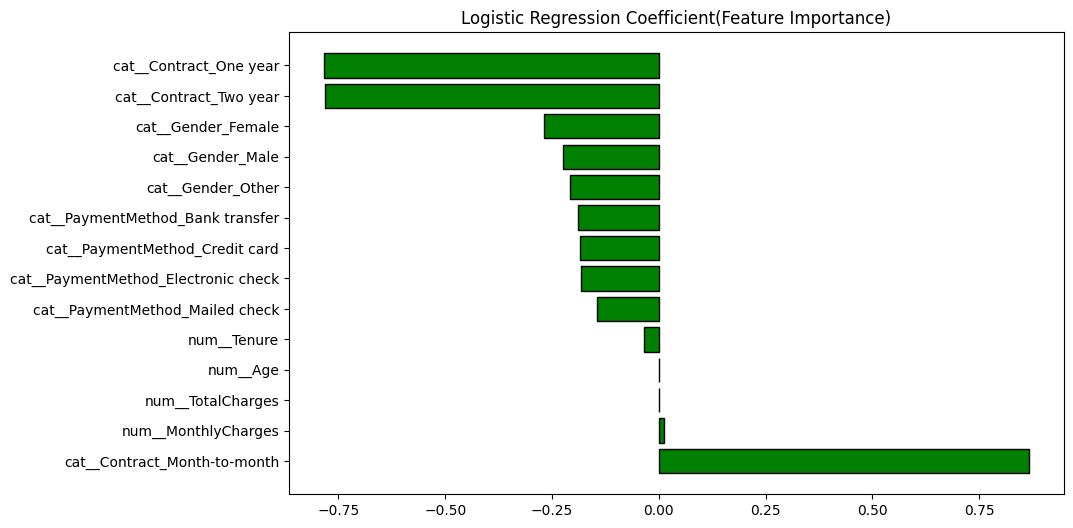

In [33]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.barh(importance["feature"],importance["Coefficient"],
        color="green",edgecolor="black")       
plt.title("Logistic Regression Coefficient(Feature Importance)")
plt.show()
